In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

In [3]:
df = pd.read_csv(data)
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [4]:
#Goal -> Making a linear regression model for predicting the car fuel efficiency:

# Preparation

In [5]:
#Feature Columns -> {'engine_displacement','horsepower','vehicle_weight','model_year'}
#Target -> 'fuel_efficiency_mpg'

In [6]:
df.head(20)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
5,2007,USA,Hybrid,Front-wheel drive,2,2290,6,266.0,4260,18.8,31.2
6,1992,Asia,Gasoline,Front-wheel drive,2,2270,6,250.0,4310,21.7,26.8
7,2005,USA,Gasoline,Front-wheel drive,4,2370,6,279.0,4090,17.4,30.2
8,1997,Asia,Gasoline,Rear-wheel drive,3,2330,6,251.0,4230,19.5,30.9
9,2004,USA,Diesel,All-wheel drive,5,2330,6,280.0,4620,17.7,31.2


In [7]:
#As drivetrain is not in our features for now, we will not fix the "-" with "_"

In [8]:
#Feature Columns -> {'engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg'}
#Target -> 'fuel_efficiency_mpg'
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [9]:
#All the columns which are gonna be features or target are already numerical columns.

# EDA

In [10]:
#Feature Columns -> {'engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg'}
#Target -> 'fuel_efficiency_mpg'

In [11]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()
    print()
    

model_year
[2006 2008 1996 1989 1994]
50


origin
<StringArray>
['Europe', 'Asia', 'USA']
Length: 3, dtype: str
3


fuel_type
<StringArray>
['Gasoline', 'Diesel', 'Hybrid']
Length: 3, dtype: str
3


drivetrain
<StringArray>
['Front-wheel drive', 'Rear-wheel drive', 'All-wheel drive']
Length: 3, dtype: str
3


num_doors
[4 5 3 2]
4


engine_displacement
[2180 2390 2320 2130 2580]
127


num_cylinders
[6 7 5 8 4]
5


horsepower
[243. 272. 267. 258. 304.]
153


vehicle_weight
[3870 4210 4240 4490 4510]
176


acceleration
[ nan 17.3 18.7 17.5 18.8]
93


fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188




In [12]:
df.fuel_efficiency_mpg.unique()  #it does have a long tail

array([31.9, 31.3, 27.5, 28.5, 31. , 31.2, 26.8, 30.2, 30.9, 31.4, 30.4,
       32.8, 35.4, 29.7, 30.1, 28. , 32.7, 26.6, 31.5, 33.8, 28.6, 30.7,
       36.9, 24.1, 25.3, 29.5, 28.2, 33.5, 27.6, 26.4, 35.2, 28.4, 29.2,
       23.8, 37.1, 24.4, 33.2, 36.6, 24.5, 29.6, 33.6, 27.1, 35.8, 36.7,
       35.6, 23.5, 31.6, 27.3, 33. , 33.9, 28.9, 31.7, 33.1, 28.7, 24.3,
       23.2, 34.3, 30.8, 26.5, 26.9, 28.8, 30.6, 26.2, 35.7, 31.1, 29.3,
       29.8, 34.6, 25. , 26.3, 30.5, 26.1, 29.4, 25.8, 34. , 29.9, 32.3,
       35.3, 34.2, 25.9, 27.7, 26.7, 30. , 34.4, 33.7, 35. , 34.5, 34.8,
       25.6, 32.5, 26. , 31.8, 27.8, 32. , 33.3, 27.9, 27.4, 28.3, 32.2,
       37.2, 30.3, 22.3, 35.9, 28.1, 39.1, 25.2, 27.2, 38.4, 24.8, 29. ,
       25.7, 36.8, 32.4, 25.4, 24.7, 33.4, 29.1, 24.2, 22.1, 36.2, 23.3,
       32.1, 23.4, 25.5, 32.9, 23.7, 25.1, 24.6, 32.6, 37.4, 27. , 34.1,
       35.5, 36.3, 23.6, 24.9, 22.7, 37.9, 23.9, 34.9, 36. , 22.4, 21.9,
       23.1, 34.7, 22.8, 37.3, 35.1, 36.4, 24. , 38

In [13]:
#----------------------------------Q1---------------------Missing value----------------------------

df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [14]:
#----------------------------------Q2---------------------Median of 'horsepower'----------------------------

df['horsepower'].median()

np.float64(254.0)

# Setting up the validation framework

In [15]:
#Feature Columns -> {'engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg'}
#Target -> 'fuel_efficiency_mpg'

In [16]:
n = len(df)
n

10000

In [17]:
#Splitting df into 3 parts -> TRAIN , VALIDATION, TEST 

# RATIO:  TRAIN:VALIDATION:TEST = 60:20:20

In [18]:
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

In [19]:
n_train, n_val , n_test 

(6000, 2000, 2000)

In [20]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [21]:
idx = np.arange(n)

In [22]:
np.random.seed(42)
np.random.shuffle(idx)

In [23]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [24]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [25]:
df_train.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
6252,2015,USA,Diesel,Front-wheel drive,3,1900,5,239.0,3790,20.3,32.5
4684,1992,USA,Gasoline,All-wheel drive,4,2000,6,224.0,4380,21.8,29.1
1731,2022,USA,Hybrid,Front-wheel drive,3,2330,6,286.0,4090,17.8,34.1
4742,1997,Asia,Gasoline,Front-wheel drive,5,2300,6,NaN,4150,19.9,30.6
4521,2001,USA,Gasoline,Front-wheel drive,4,2340,6,269.0,4400,18.6,30.7


In [26]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [27]:
df_train.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2015,USA,Diesel,Front-wheel drive,3,1900,5,239.0,3790,20.3,32.5
1,1992,USA,Gasoline,All-wheel drive,4,2000,6,224.0,4380,21.8,29.1
2,2022,USA,Hybrid,Front-wheel drive,3,2330,6,286.0,4090,17.8,34.1
3,1997,Asia,Gasoline,Front-wheel drive,5,2300,6,NaN,4150,19.9,30.6
4,2001,USA,Gasoline,Front-wheel drive,4,2340,6,269.0,4400,18.6,30.7


In [28]:
# Extracting target from our splits and also concising the target with log transformation.

y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values) 
y_test = np.log1p(df_test.fuel_efficiency_mpg.values) 


In [29]:
#deleting the target from all 3 splits:
del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']


In [30]:
df_train

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration
0,2015,USA,Diesel,Front-wheel drive,3,1900,5,239.0,3790,20.3
1,1992,USA,Gasoline,All-wheel drive,4,2000,6,224.0,4380,21.8
2,2022,USA,Hybrid,Front-wheel drive,3,2330,6,286.0,4090,17.8
3,1997,Asia,Gasoline,Front-wheel drive,5,2300,6,NaN,4150,19.9
4,2001,USA,Gasoline,Front-wheel drive,4,2340,6,269.0,4400,18.6
...,...,...,...,...,...,...,...,...,...,...
5995,2018,Asia,Gasoline,Rear-wheel drive,4,2280,6,242.0,4590,20.5
5996,1984,Europe,Gasoline,Front-wheel drive,2,2300,6,NaN,4240,18.1
5997,1989,USA,Gasoline,Front-wheel drive,3,2240,6,255.0,4190,17.2
5998,2020,Europe,Gasoline,Rear-wheel drive,5,2430,6,254.0,4280,18.4


In [31]:
y_train

array([3.51154544, 3.40452517, 3.55820113, ..., 3.35689712, 3.48431229,
       3.36729583], shape=(6000,))

# Filling Missing Values as 0 

In [32]:
#Feature Columns -> {'engine_displacement','horsepower','vehicle_weight','model_year'}
#Target -> 'fuel_efficiency_mpg'

In [33]:
#first i will make a copy of all dataframes for this experiment: df_zero_

df_zero_train = df_train.copy()
df_zero_val = df_val.copy()
df_zero_test = df_test.copy()

In [34]:
df_zero_train.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             538
vehicle_weight           0
acceleration           156
dtype: int64

In [35]:
#now lets fill missing value 'horsepower' with 0, in all 3 df:

df_zero_train['horsepower'] = df_zero_train['horsepower'].fillna(0)
df_zero_val['horsepower'] = df_zero_val['horsepower'].fillna(0)
df_zero_test['horsepower'] = df_zero_test['horsepower'].fillna(0)

## Linear regression model - training

In [36]:
features = ['engine_displacement','horsepower','vehicle_weight','model_year']

In [37]:
X_zero_train = df_zero_train[features].values
X_zero_train

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [38]:
ones = np.ones(len(df_zero_train))
X_zero_train = np.column_stack([ones, X_zero_train])   #adding vias to the feature matrix
X_zero_train  #feature matrix with added bias

array([[1.000e+00, 1.900e+03, 2.390e+02, 3.790e+03, 2.015e+03],
       [1.000e+00, 2.000e+03, 2.240e+02, 4.380e+03, 1.992e+03],
       [1.000e+00, 2.330e+03, 2.860e+02, 4.090e+03, 2.022e+03],
       ...,
       [1.000e+00, 2.240e+03, 2.550e+02, 4.190e+03, 1.989e+03],
       [1.000e+00, 2.430e+03, 2.540e+02, 4.280e+03, 2.020e+03],
       [1.000e+00, 2.390e+03, 2.660e+02, 4.220e+03, 1.996e+03]],
      shape=(6000, 5))

In [39]:
y_train #target vector

array([3.51154544, 3.40452517, 3.55820113, ..., 3.35689712, 3.48431229,
       3.36729583], shape=(6000,))

In [40]:
def train_linear_regression(X, y):
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.pinv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full

In [41]:
w_zero_full = train_linear_regression(X_zero_train, y_train)
w_zero_full

array([-2.54887981e+00, -4.93996325e-05,  3.99285517e-06, -1.29300048e-04,
        3.32220817e-03])

In [42]:
#RMSE

def rmse(y, y_pred):
    error = y-y_pred
    se = error**2
    mse = se.mean()
    return np.sqrt(mse)


## Linear regression model - validation

In [43]:
#validation feature matrix

X_zero_val = df_zero_val[features].values
ones = np.ones(len(df_zero_val))
X_zero_val = np.column_stack([ones, X_zero_val])   #adding vias to the feature matrix
X_zero_val  #feature matrix with added bias

array([[1.000e+00, 2.240e+03, 2.650e+02, 3.990e+03, 2.004e+03],
       [1.000e+00, 2.390e+03, 2.590e+02, 4.770e+03, 2.019e+03],
       [1.000e+00, 2.360e+03, 2.650e+02, 4.320e+03, 2.018e+03],
       ...,
       [1.000e+00, 2.390e+03, 2.640e+02, 4.550e+03, 2.017e+03],
       [1.000e+00, 2.330e+03, 2.440e+02, 4.440e+03, 2.014e+03],
       [1.000e+00, 2.170e+03, 2.600e+02, 4.460e+03, 2.021e+03]],
      shape=(2000, 5))

In [44]:
y_zero_pred_val = X_zero_val.dot(w_zero_full)
y_zero_pred_val

array([3.48332111, 3.42486629, 3.48123505, ..., 3.44668785, 3.45382835,
       3.48246563], shape=(2000,))

In [45]:
rmse_zero = rmse(y_val, y_zero_pred_val) #RMSE counted on - y-validation and y prediction-zero-validation
rmse_zero = round(rmse_zero, 3)
rmse_zero

np.float64(0.071)

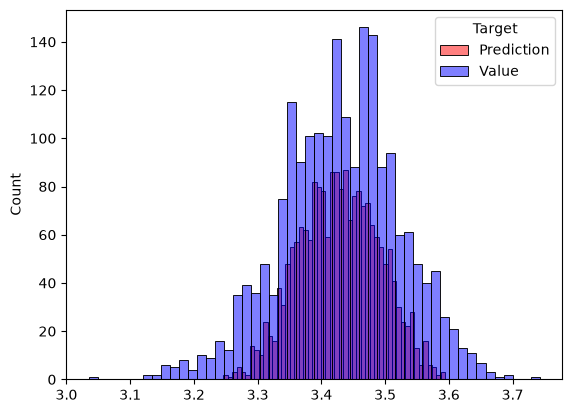

In [46]:
sns.histplot(y_zero_pred_val, color="red", alpha = 0.5 , bins = 50)
sns.histplot(y_val, color="blue", alpha = 0.5 , bins = 50)
plt.legend(title="Target", labels=["Prediction", "Value"])

# Filling Missing Values as Mean(Training)

In [47]:
#Feature Columns -> {'engine_displacement','horsepower','vehicle_weight','model_year'}
#Target -> 'fuel_efficiency_mpg'

In [48]:
#first i will make a copy of all dataframes for this experiment: df_mean_

df_mean_train = df_train.copy()
df_mean_val = df_val.copy()
df_mean_test = df_test.copy()

In [49]:
df_mean_train.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             538
vehicle_weight           0
acceleration           156
dtype: int64

In [50]:
#mean training
mean_factor = df_mean_train['horsepower'].mean()
mean_factor

np.float64(254.46338337605272)

In [51]:
#now lets fill missing value 'horsepower' with mean(training), in all 3 df:

df_mean_train['horsepower'] = df_zero_train['horsepower'].fillna(mean_factor)
df_mean_val['horsepower'] = df_zero_val['horsepower'].fillna(mean_factor)
df_mean_test['horsepower'] = df_zero_test['horsepower'].fillna(mean_factor)

## Linear regression model - training

In [52]:
#Feature Columns -> {'engine_displacement','horsepower','vehicle_weight','model_year'}
#Target -> 'fuel_efficiency_mpg'

In [53]:
features = ['engine_displacement','horsepower','vehicle_weight','model_year']

In [54]:
X_mean_train = df_mean_train[features].values
ones = np.ones(len(df_mean_train))
X_mean_train = np.column_stack([ones, X_mean_train])   #adding bias to the feature matrix
X_mean_train  #feature matrix with added bias

array([[1.000e+00, 1.900e+03, 2.390e+02, 3.790e+03, 2.015e+03],
       [1.000e+00, 2.000e+03, 2.240e+02, 4.380e+03, 1.992e+03],
       [1.000e+00, 2.330e+03, 2.860e+02, 4.090e+03, 2.022e+03],
       ...,
       [1.000e+00, 2.240e+03, 2.550e+02, 4.190e+03, 1.989e+03],
       [1.000e+00, 2.430e+03, 2.540e+02, 4.280e+03, 2.020e+03],
       [1.000e+00, 2.390e+03, 2.660e+02, 4.220e+03, 1.996e+03]],
      shape=(6000, 5))

In [55]:
y_train

array([3.51154544, 3.40452517, 3.55820113, ..., 3.35689712, 3.48431229,
       3.36729583], shape=(6000,))

In [56]:
w_mean_full = train_linear_regression(X_mean_train, y_train)
w_mean_full

array([-2.54887981e+00, -4.93996325e-05,  3.99285517e-06, -1.29300048e-04,
        3.32220817e-03])

## Linear regression model - validation

In [57]:
#validation feature matrix

X_mean_val = df_mean_val[features].values
ones = np.ones(len(df_zero_val))
X_mean_val = np.column_stack([ones, X_mean_val])   #adding bias to the feature matrix
X_mean_val  #feature matrix with added bias

array([[1.000e+00, 2.240e+03, 2.650e+02, 3.990e+03, 2.004e+03],
       [1.000e+00, 2.390e+03, 2.590e+02, 4.770e+03, 2.019e+03],
       [1.000e+00, 2.360e+03, 2.650e+02, 4.320e+03, 2.018e+03],
       ...,
       [1.000e+00, 2.390e+03, 2.640e+02, 4.550e+03, 2.017e+03],
       [1.000e+00, 2.330e+03, 2.440e+02, 4.440e+03, 2.014e+03],
       [1.000e+00, 2.170e+03, 2.600e+02, 4.460e+03, 2.021e+03]],
      shape=(2000, 5))

In [58]:
y_mean_pred_val = X_mean_val.dot(w_mean_full)
y_mean_pred_val

array([3.48332111, 3.42486629, 3.48123505, ..., 3.44668785, 3.45382835,
       3.48246563], shape=(2000,))

In [59]:
rmse_mean = rmse(y_val, y_mean_pred_val) #RMSE counted on - y-validation and y prediction-mean-validation
rmse_mean = round(rmse_mean, 3)
rmse_mean

np.float64(0.071)

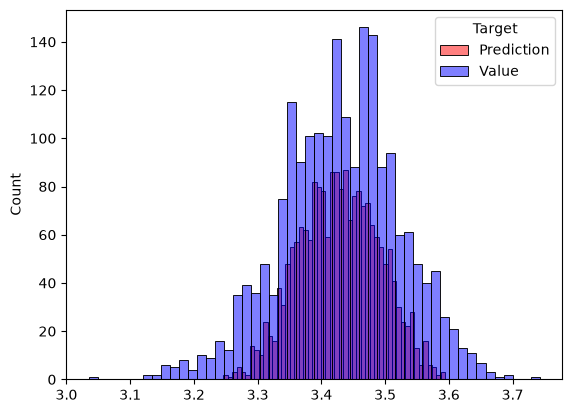

In [60]:
sns.histplot(y_mean_pred_val, color="red", alpha = 0.5 , bins = 50)
sns.histplot(y_val, color="blue", alpha = 0.5 , bins = 50)
plt.legend(title="Target", labels=["Prediction", "Value"])

# Difference B/w RMSE 

In [61]:
#Q3-----------------------------------------WHICH RMSE IS BETTER--------------------------------

print("RMSE ZERO ->",rmse_zero)
print("RMSE MEAN(TRAINING) ->",rmse_mean)

RMSE ZERO -> 0.071
RMSE MEAN(TRAINING) -> 0.071


In [62]:
#as we can see Both are same

# Model Tuning (Regularization)

In [63]:
def prepare_X(df):
    df_num = df.copy()
    df_num = df_num[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    ones = np.ones(len(df))
    X = np.column_stack([ones,X])
    return X

In [64]:
def train_linear_regression_reg(X, y, r=0.001):
    XTX = X.T.dot(X)
    
    XTX = XTX + r * np.eye(XTX.shape[0]) #we have added synthetic (alpha-> r) in the form of identity matrix, to avoid duplicate values of features.
    
    XTX_inv = np.linalg.pinv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full

In [65]:
#Q4--------------------------------------------- Best alpha for regularization--------------------------------------

#Now we will try to find the best value of alpha/ Regularization parameter for our model:

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:  #sample of different alpha's we can take, according to the lowest RMSE:
    X_train = prepare_X(df_train)
    
    w_full = train_linear_regression_reg(X_train, y_train, r=r)  
    
    X_val = prepare_X(df_val) 
    
    y_pred = X_val.dot(w_full)
    
    score = rmse(y_val, y_pred) 

    print(r, " " , w_full[0], " ", round(score,4))

0   -2.5488798138412916   0.0715
0.01   -2.456525721469829   0.0715
0.1   -1.8524447855056714   0.0717
1   -0.535529559364676   0.0727
5   -0.12874519245207883   0.0733
10   -0.06603998135001726   0.0734
100   -0.006760761167266575   0.0735


In [66]:
#As 0 and 0.01 both are giving same rmse, so will take smallest alpha which is 0.

# Different Seed values

In [67]:
#Feature Columns -> {'engine_displacement','horsepower','vehicle_weight','model_year'}
#Target -> 'fuel_efficiency_mpg'

def train_linear_regression(X, y):
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.pinv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full
    
def calc_rmse(df, seed):
    df = df.copy()
    df['horsepower'] = df['horsepower'].fillna(0)
    n = len(df)
    n_val = int(n*0.2)
    n_test = int(n*0.2)
    n_train = n - n_val - n_test
    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]

    #dropping index
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    
    # Extracting target from our splits and also concising the target with log transformation.
    y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
    y_val = np.log1p(df_val.fuel_efficiency_mpg.values) 
    y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

    #deleting the target from all 3 splits:
    del df_train['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']

    #training and prediction

    features = ['engine_displacement','horsepower','vehicle_weight','model_year']

    X_train = df_train[features].values
    ones = np.ones(len(df_train))
    X_train = np.column_stack([ones, X_train])   #adding bias to the feature matrix
    X_train  #feature matrix with added bias

    w_full = train_linear_regression(X_train, y_train)

    #validation feature matrix
    
    X_val = df_val[features].values
    ones = np.ones(len(df_val))
    X_val = np.column_stack([ones, X_val])   #adding bias to the feature matrix
    X_val  #feature matrix with added bias

    y_pred_val = X_val.dot(w_full)

    rmse_value = rmse(y_val, y_pred_val) #RMSE counted on - y-validation and y prediction-validation

    return rmse_value


In [71]:
#Q5--------------------------------------Different seeds- rmse value's standard deviation----------------------

seed_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = np.array([])


for i in seed_values:
    s = calc_rmse(df, i)
    rmse_scores = np.append(rmse_scores,s)

std = np.std(rmse_scores, ddof=1)
print(round(std,3))

0.001


# Final test

In [73]:
df_c = df.copy()
df_c['horsepower'] = df_c['horsepower'].fillna(0)
n = len(df_c)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test
idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)
df_train = df_c.iloc[idx[:n_train]]
df_val = df_c.iloc[idx[n_train:n_train+n_val]]
df_test = df_c.iloc[idx[n_train+n_val:]]

#dropping index
df_full = pd.concat([df_train, df_val], ignore_index=True)
df_test = df_test.reset_index(drop=True)

# Extracting target from our splits and also concising the target with log transformation.
y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_full = np.concatenate([y_train, y_val], axis=0)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

#deleting the target from both splits:
del df_full['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

In [80]:
def prepare_X(df):
    df_num = df[features]
    X = df_num.values
    ones = np.ones(len(df))
    X = np.column_stack([ones,X])
    return X

In [81]:
def train_linear_regression_reg(X, y, r=0.001):
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0]) 
    XTX_inv = np.linalg.pinv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full

In [82]:
def rmse(y, y_pred):
    error = y-y_pred
    se = error**2
    mse = se.mean()
    return np.sqrt(mse)


In [84]:
X_full = prepare_X(df_full)
w_full = train_linear_regression_reg(X_full, y_full)
X_test = prepare_X(df_test)
y_pred = X_test.dot(w_full)  
score = rmse(y_test, y_pred)
score

np.float64(0.0721308868369263)